   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.3815

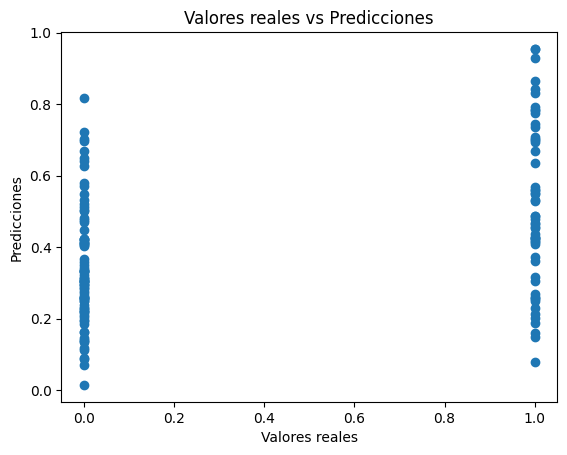

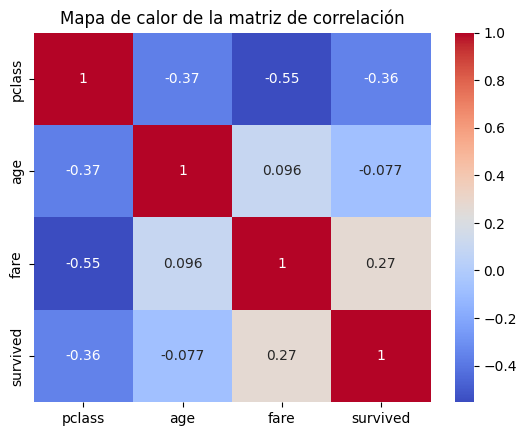

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
# cargar el dataset de vuelos
data = sns.load_dataset('titanic')
# muestra las primeras filas del dataset
print(data.head())
# validar los tipos de datos y la información general del dataset
print(data.describe())
print(data.shape)
# seleccionar las características relevantes para el análisis
features = ['pclass', 'age', 'fare', 'survived']
data = data[features]
# eliminar filas con valores faltantes
data = data.dropna()

# Seleccionar las características y la variable objetivo
X = data.drop(columns=['survived'])  # Select features, drop the target variable
y = data['survived']  # Select the target variable
# Dividir el dataset en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Crear el modelo de regresión lineal
model = LinearRegression()
# Entrenar el modelo
# No hay columna 'month' en este dataset; usar X_train y X_test tal cual (son numéricos)
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()
model.fit(X_train_encoded, y_train)
# Hacer predicciones
y_pred = model.predict(X_test_encoded)
# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')
# Visualizar los resultados
plt.scatter(y_test, y_pred)
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.title('Valores reales vs Predicciones')
plt.show()
# mapa de calor de la matriz de correlación
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Mapa de calor de la matriz de correlación')
plt.show()

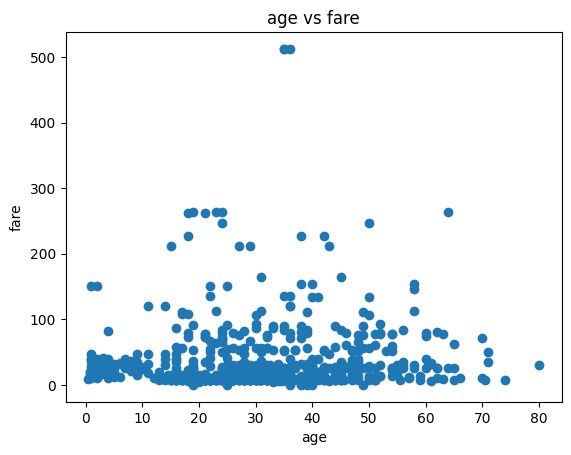

In [17]:
x=data['age']
y=data['fare']
plt.scatter(x,y)
plt.xlabel('age')
plt.ylabel('fare')
plt.title('age vs fare')
plt.show()

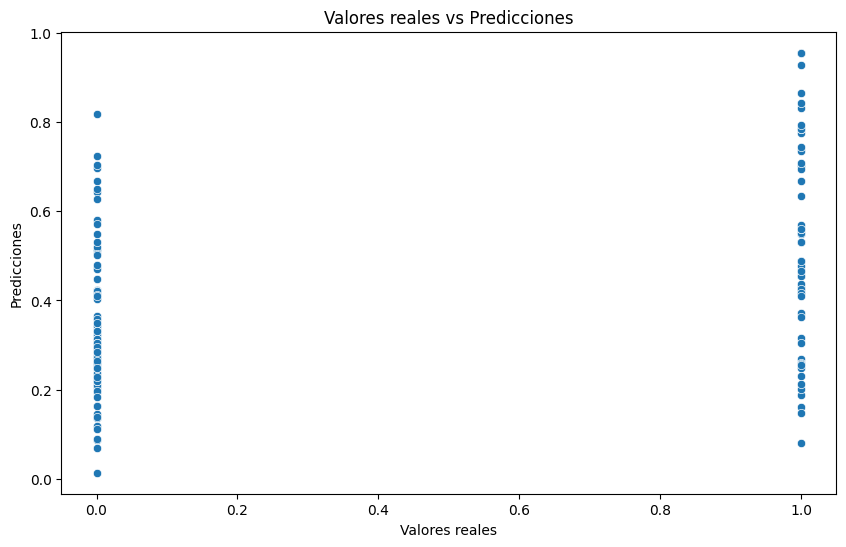

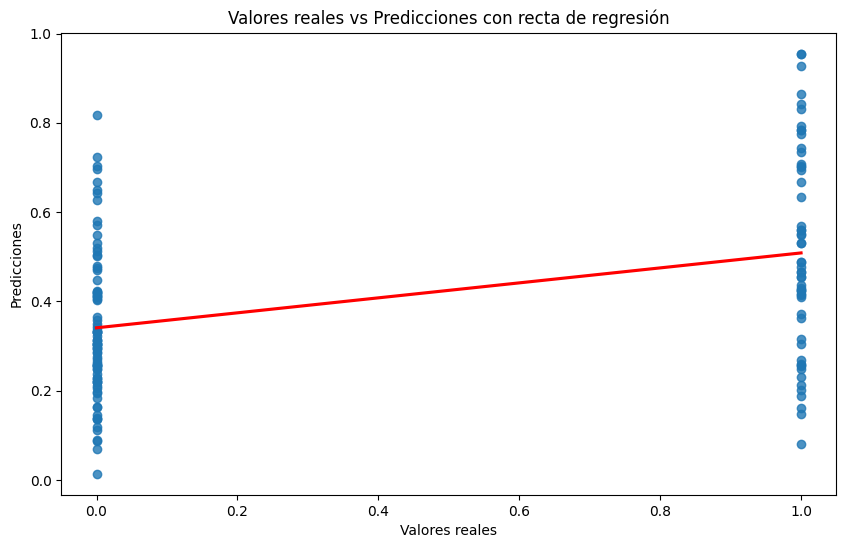

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test.reset_index(drop=True), y=y_pred)
plt.title('Valores reales vs Predicciones')
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.show()
#recta de regresión
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test.reset_index(drop=True), y=y_pred, ci=None, line_kws={'color': 'red'})
plt.title('Valores reales vs Predicciones con recta de regresión')
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.show()